# Day 2 · 06. Adaptive RAG — 데이터소스 라우팅 (vectorstore vs web_search)

**학습 목표**

- 질문 주제에 따라 **로컬 벡터스토어 vs 웹 검색** 중 어느 데이터소스를 쓸지 결정하는 라우터를 만든다
- 벡터스토어 경로에서 **문서 관련성 그레이더**로 저품질 검색을 걸러내고, 필요하면 쿼리를 재작성해 다시 검색한다
- 이 모든 것을 LangGraph `StateGraph`로 엮어 "적응형" RAG 워크플로우를 구축한다

> 참고: 이 노트북은 [wikidocs — Adaptive RAG](https://wikidocs.net/267814) 구성을 바탕으로 한국어 교육용으로 재구성했다.

## Adaptive RAG이란?

일반 RAG는 **항상 벡터스토어를 검색**한다. 그러나 실제 질문은 다양하다.

- "전자금융거래법이 규정하는 망분리 요건은?" → **내부 문서**가 답한다
- "오늘 미국 증시 주요 이슈는?" → **외부 웹**이 답한다

**Adaptive RAG**는 질문을 분류해 **검색 경로 자체를 바꾼다**.

### 이 노트북의 2-way 라우팅

```
질문 → [라우터] ─┬─ vectorstore → 검색 → [관련성 평가] ─┬─ 관련 O → 답변
                │                                      └─ 관련 X → 쿼리 재작성 → 재검색
                └─ web_search  → 검색 ──────────────────→ 답변
```

### Self-RAG(05)와의 차이

| 05 Self-RAG | 06 Adaptive RAG |
|-------------|-----------------|
| 검색 **후** 품질 평가 | 검색 **전** 경로 선택 + 검색 후 품질 평가 |
| 단일 데이터소스 | 다중 데이터소스 (내부 DB + 웹) |
| "잘못 검색했으면 재시도" | "애초에 어디서 찾을지 먼저 결정" |

## 섹션 1 · Create Index — 인덱스 생성 및 문서 로드

01~05와 동일한 한국어 금융 규제 코퍼스(`data/corpus_ko.txt`)를 **FAISS**로 인덱싱한다.
검색기(retriever)는 상위 3개(k=3) 청크를 반환한다.

In [1]:
import sys
sys.path.insert(0, '..')  # common 모듈 경로 확보

from common import get_chat_model, get_embeddings, provider_badge
from common.loaders import load_any
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. 문서 로드 & 분할
docs = load_any('../data/corpus_ko.txt')
splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=80)
chunks = splitter.split_documents(docs)

# 2. FAISS 벡터스토어 (01-05와 동일 패턴)
vectorstore = FAISS.from_documents(chunks, get_embeddings())
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

# 3. LLM은 라우터·그레이더·답변 생성에 공통으로 사용
llm = get_chat_model(temperature=0)

print(provider_badge())
print(f'chunks={len(chunks)}, retriever k=3')

☁️ OpenAI | model=openai/gpt-4o-mini
chunks=4, retriever k=3


## 섹션 2 · LLMs — 쿼리 라우팅 & 문서 평가

LLM을 세 곳에서 쓴다.

1. **question_router** — 질문을 `vectorstore` / `web_search`로 분류 (구조화 출력)
2. **retrieval_grader** — 검색된 문서가 질문과 관련 있는지 yes/no (구조화 출력)
3. **question_rewriter** — 검색 실패 시 질문을 재작성 (일반 문자열)

구조화 출력은 **Pydantic + `llm.with_structured_output()`** 조합으로 타입 안전하게 받는다.

In [2]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


class RouteQuery(BaseModel):
    """사용자 질문을 가장 적절한 데이터소스로 라우팅."""
    datasource: Literal['vectorstore', 'web_search'] = Field(
        ...,
        description="내부 벡터스토어(금융 IT 규제) 관련이면 'vectorstore', "
                    "최신 뉴스·일반 웹 정보면 'web_search'."
    )


route_system = """당신은 사용자 질문을 '벡터스토어'와 '웹 검색' 두 경로 중 하나로 보내는 라우터다.

벡터스토어에는 다음 주제의 한국어 문서가 들어있다:
- 전자금융거래법
- 금융권 망분리 요건
- 전자금융감독규정

이 주제와 관련된 질문이면 'vectorstore', 그렇지 않으면(최신 뉴스, 일반 상식, 시사 등) 'web_search'로 분류하라."""

route_prompt = ChatPromptTemplate.from_messages([
    ('system', route_system),
    ('human', '{question}'),
])
question_router = route_prompt | llm.with_structured_output(RouteQuery)

# 테스트: 금융 질문과 일반 질문
for q in ['전자금융거래법이 규정하는 망분리 요건은?', '오늘 날씨 어때?']:
    decision = question_router.invoke({'question': q})
    print(f'  {q!r:55s} → {decision.datasource}')

  '전자금융거래법이 규정하는 망분리 요건은?'                                → vectorstore


  '오늘 날씨 어때?'                                             → web_search


In [3]:
class GradeDocuments(BaseModel):
    """검색된 문서의 질문 관련성을 이진 판정."""
    binary_score: Literal['yes', 'no'] = Field(
        ...,
        description="문서가 질문과 관련 있으면 'yes', 아니면 'no'."
    )


grade_system = """너는 검색된 문서가 사용자 질문과 관련 있는지 평가하는 평가자다.
문서에 질문의 키워드나 의미상 관련된 내용이 있으면 'yes'로 판정한다.
엄격할 필요는 없다. 목표는 **명백히 무관한 문서만 걸러내는** 것이다."""

grade_prompt = ChatPromptTemplate.from_messages([
    ('system', grade_system),
    ('human', '검색된 문서:\n\n{document}\n\n사용자 질문:\n{question}'),
])
retrieval_grader = grade_prompt | llm.with_structured_output(GradeDocuments)

# 테스트: 관련 있을 법한 문서와 뜬금없는 문서
sample_docs = retriever.invoke('망분리')
print('1) 검색으로 얻은 문서:')
print(f'   → {retrieval_grader.invoke({"question": "망분리 요건?", "document": sample_docs[0].page_content[:200]}).binary_score}')
print('2) 완전히 뜬금없는 문서:')
print(f'   → {retrieval_grader.invoke({"question": "망분리 요건?", "document": "오늘 점심 메뉴는 김치찌개였다."}).binary_score}')

1) 검색으로 얻은 문서:


   → yes
2) 완전히 뜬금없는 문서:


   → no


In [4]:
from langchain_core.output_parsers import StrOutputParser

rewrite_system = """너는 벡터스토어 검색에 더 잘 맞도록 질문을 **다시 쓰는** 리라이터다.
원 질문의 의도·핵심 개념을 유지한 채, 검색 키워드가 선명해지도록 한 줄로 재작성하라.
출력은 재작성된 질문 한 줄만."""

rewrite_prompt = ChatPromptTemplate.from_messages([
    ('system', rewrite_system),
    ('human', '원 질문: {question}\n\n재작성한 질문:'),
])
question_rewriter = rewrite_prompt | llm | StrOutputParser()

# 테스트
original = '그거 뭐였지, 금융권 IT 망 나누는 거?'
print(f'원본   : {original}')
print(f'재작성 : {question_rewriter.invoke({"question": original}).strip()}')

원본   : 그거 뭐였지, 금융권 IT 망 나누는 거?


재작성 : 금융권 IT 망 분리란 무엇인가?


## 섹션 3 · Web Search Tool — 웹 검색 도구 설정

벡터스토어에 없는 질문은 **웹 검색**으로 보낸다. API 키 없이 바로 쓸 수 있는 **DuckDuckGo**를 사용한다.

> 폐쇄망 환경에서는 이 자리에 사내 문서 DB나 기업 검색 API를 꽂으면 된다. 여기서는 교육 목적상 공용 웹 검색을 예시로 쓴다.

In [5]:
from langchain_community.tools import DuckDuckGoSearchResults

# output_format='list' → 결과를 [{'snippet', 'title', 'link'}, ...] 리스트로 반환
web_search_tool = DuckDuckGoSearchResults(num_results=3, output_format='list')

sample = web_search_tool.invoke('Anthropic Claude 최신 소식')
print(f'타입: {type(sample).__name__}, 결과 수: {len(sample) if isinstance(sample, list) else "N/A"}')
for item in (sample if isinstance(sample, list) else [])[:2]:
    print(f"  - {item.get('title', '')[:60]}")
    print(f"    {item.get('link', '')}")

타입: list, 결과 수: 3
  - Newsroom \ Anthropic
    https://www.anthropic.com/news
  - [Opus 4.7 출시] Anthropic Claude Code 최신 AI 모델 완벽 정리
    https://observerlife.tistory.com/303


## 섹션 4 · Construct the Graph — 상태 및 흐름 정의

`GraphState`는 그래프를 흐르는 **공용 배낭**이다. 노드들은 배낭에서 값을 꺼내 일을 하고, 갱신한 값을 다시 넣어 다음 노드로 넘긴다.

### 노드 5개 & 조건 라우터 2개

| 종류 | 이름 | 역할 |
|------|------|------|
| 노드 | `retrieve` | 벡터스토어 검색 |
| 노드 | `web_search` | 웹 검색 |
| 노드 | `grade_documents` | 검색 결과 관련성 평가 |
| 노드 | `transform_query` | 질문 재작성 |
| 노드 | `generate` | 최종 답변 생성 |
| 라우터 | `route_question` | 시작점에서 vectorstore vs web_search 분기 |
| 라우터 | `decide_to_generate` | 관련 문서 남았으면 generate, 아니면 transform_query |

In [6]:
from typing import TypedDict
from langchain_core.documents import Document


class GraphState(TypedDict):
    question: str
    generation: str
    documents: list[Document]


# ---------- 노드 함수 ----------

def retrieve(state: GraphState) -> dict:
    """벡터스토어에서 k=3 문서 가져오기."""
    print('--- [RETRIEVE] 벡터스토어 검색 ---')
    return {'documents': retriever.invoke(state['question']), 'question': state['question']}


def web_search(state: GraphState) -> dict:
    """DuckDuckGo 결과를 Document로 변환."""
    print('--- [WEB_SEARCH] 웹 검색 ---')
    results = web_search_tool.invoke(state['question'])
    docs = [Document(page_content=r.get('snippet', ''), metadata={'source': r.get('link', '')})
            for r in (results if isinstance(results, list) else [])]
    return {'documents': docs, 'question': state['question']}


def grade_documents(state: GraphState) -> dict:
    """문서별로 관련성 평가하여 관련 있는 것만 남긴다."""
    print('--- [GRADE_DOCUMENTS] 관련성 평가 ---')
    kept = []
    for d in state['documents']:
        verdict = retrieval_grader.invoke({'question': state['question'], 'document': d.page_content})
        if verdict.binary_score == 'yes':
            kept.append(d)
    print(f'   → 관련 문서 {len(kept)} / {len(state["documents"])} 건 유지')
    return {'documents': kept, 'question': state['question']}


def transform_query(state: GraphState) -> dict:
    """질문을 검색에 더 적합하게 재작성."""
    print('--- [TRANSFORM_QUERY] 질문 재작성 ---')
    new_q = question_rewriter.invoke({'question': state['question']}).strip()
    print(f'   → {state["question"]!r} → {new_q!r}')
    return {'documents': state['documents'], 'question': new_q}


def generate(state: GraphState) -> dict:
    """검색 결과를 근거로 최종 답변 생성."""
    print('--- [GENERATE] 답변 생성 ---')
    context = '\n\n'.join(d.page_content for d in state['documents'])
    prompt = ChatPromptTemplate.from_template(
        '다음 컨텍스트만을 참고해 질문에 답하라. 컨텍스트에 없으면 모른다고 말하라.\n\n'
        '컨텍스트:\n{context}\n\n질문: {question}\n\n답변:'
    )
    chain = prompt | llm | StrOutputParser()
    return {'generation': chain.invoke({'context': context, 'question': state['question']})}


# ---------- 조건 라우터 ----------

def route_question(state: GraphState) -> str:
    """시작점에서 어느 경로로 갈지 결정."""
    print('--- [ROUTE_QUESTION] 경로 결정 ---')
    decision = question_router.invoke({'question': state['question']})
    print(f'   → {decision.datasource}')
    return decision.datasource  # 'vectorstore' | 'web_search'


def decide_to_generate(state: GraphState) -> str:
    """관련 문서가 하나라도 있으면 답변, 없으면 재작성."""
    if not state['documents']:
        print('--- [DECISION] 관련 문서 없음 → 쿼리 재작성 ---')
        return 'transform_query'
    print('--- [DECISION] 관련 문서 있음 → 답변 생성 ---')
    return 'generate'

## 섹션 5 · Compile Graph — 그래프 컴파일 & 워크플로우 구축

`StateGraph`에 노드와 엣지를 조립하고 `.compile()`로 실행 가능한 앱을 만든다.

### 엣지 조립 규칙

- `START → route_question → {vectorstore→retrieve, web_search→web_search}`
- `retrieve → grade_documents → {관련O→generate, 관련X→transform_query}`
- `transform_query → retrieve` (재검색 루프)
- `web_search → generate`
- `generate → END`

In [7]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

workflow.add_node('retrieve', retrieve)
workflow.add_node('web_search', web_search)
workflow.add_node('grade_documents', grade_documents)
workflow.add_node('transform_query', transform_query)
workflow.add_node('generate', generate)

# 진입점: 라우터가 가리키는 곳으로
workflow.add_conditional_edges(
    START, route_question,
    {'vectorstore': 'retrieve', 'web_search': 'web_search'},
)

# 벡터스토어 경로
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents', decide_to_generate,
    {'generate': 'generate', 'transform_query': 'transform_query'},
)
workflow.add_edge('transform_query', 'retrieve')  # 재검색 루프

# 웹 검색 경로
workflow.add_edge('web_search', 'generate')

# 종료
workflow.add_edge('generate', END)

app = workflow.compile()
print('컴파일 완료')

컴파일 완료


--- Mermaid DSL (텍스트) ---
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	web_search(web_search)
	grade_documents(grade_documents)
	transform_query(transform_query)
	generate(generate)
	__end__([<p>__end__</p>]):::last
	generate --> __end__;
	retrieve --> grade_documents;
	transform_query --> retrieve;
	web_search --> generate;
	__start__ -. &nbsp;vectorstore&nbsp; .-> retrieve;
	__start__ -.-> web_search;
	grade_documents -.-> generate;
	grade_documents -.-> transform_query;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



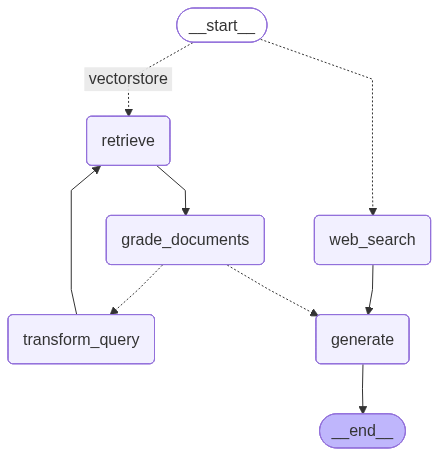

In [8]:
# 시각화 1: Mermaid DSL 텍스트 (폐쇄망·airgap에서도 안전)
print('--- Mermaid DSL (텍스트) ---')
print(app.get_graph().draw_mermaid())

# 시각화 2: PNG (mermaid.ink 외부 API 호출이 가능한 환경에서만 동작)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f'\n[PNG 렌더 실패 — 텍스트 버전으로 대체] {type(e).__name__}: {e}')

## 섹션 6 · Use Graph — 그래프 실행 & 결과 확인

두 개의 대조적인 질문을 던져 **라우터가 실제로 경로를 바꾸는지** 눈으로 확인한다.

In [9]:
# 예제 1: 벡터스토어 경로로 가야 할 질문
print('=' * 70)
print('예제 1: 금융권 망분리 질문 → vectorstore 경로 기대')
print('=' * 70)

result1 = app.invoke({'question': '금융권에서 말하는 망분리가 무엇이고 왜 하는가?'})
print('\n[최종 답변]')
print(result1['generation'])

예제 1: 금융권 망분리 질문 → vectorstore 경로 기대
--- [ROUTE_QUESTION] 경로 결정 ---


   → vectorstore
--- [RETRIEVE] 벡터스토어 검색 ---


--- [GRADE_DOCUMENTS] 관련성 평가 ---


   → 관련 문서 1 / 3 건 유지
--- [DECISION] 관련 문서 있음 → 답변 생성 ---
--- [GENERATE] 답변 생성 ---



[최종 답변]
망분리는 금융권 보안의 핵심 원칙으로, 업무망과 인터넷망을 물리적 또는 논리적으로 분리하여 외부 침해로부터 내부 시스템을 보호하는 것을 목적으로 합니다. 이는 전산실 및 정보처리시스템이 인터넷과 분리된 망에서 운영되어야 한다는 전자금융감독규정에 따라 이루어집니다.


In [10]:
# 예제 2: 웹 검색 경로로 가야 할 질문
print('=' * 70)
print('예제 2: 일반 상식/사실 질문 → web_search 경로 기대')
print('=' * 70)

result2 = app.invoke({'question': 'Python 프로그래밍 언어는 누가 만들었나?'})
print('\n[최종 답변]')
print(result2['generation'])

예제 2: 일반 상식/사실 질문 → web_search 경로 기대
--- [ROUTE_QUESTION] 경로 결정 ---


   → web_search
--- [WEB_SEARCH] 웹 검색 ---


--- [GENERATE] 답변 생성 ---



[최종 답변]
Python 프로그래밍 언어는 귀도 반 로섬이 만들었습니다.


## 정리

이 노트북에서 만든 **최소 Adaptive RAG**는

1. **2-way 라우팅** (vectorstore vs web_search) — 질문의 주제에 따라 데이터소스를 선택
2. **문서 관련성 루프** — 검색 결과가 부실하면 질문을 재작성해 다시 검색

### 05 Self-RAG 대비 무엇이 달라졌나

- 05는 **단일 데이터소스**에서 "검색 후 품질 평가"
- 06은 여기에 **"검색 전 경로 선택"**을 더해 외부 지식(웹)에도 대응

### 더 나아가려면

- 라우팅 경로를 3-way/N-way로 확장 (예: `vectorstore` / `web_search` / `calculator`)
- 답변에 대한 **환각 검증(hallucination grader)** · **답변 적절성 검증(answer grader)** 루프 추가 ([wikidocs 원본](https://wikidocs.net/267814) 참조)
- `web_search`를 사내 문서 DB·기업 검색 API로 교체 (실제 폐쇄망 대응)